# 02 · U.S. Retail Sales Forecast

**Decision:** create a national retail-sales planning range and test whether the method improves on “same month last year.”

**Data:** U.S. Census Bureau via FRED series `RSAFSNA`, monthly millions of dollars, not seasonally adjusted.


## 1. Why this series

The not-seasonally-adjusted series retains recurring calendar patterns, making a seasonal forecast appropriate. It is a U.S. macro indicator—not company, store, category, or SKU demand—so operational recommendations must stay at the planning level.


In [1]:
from pathlib import Path
import sys

PROJECT_DIR = Path.cwd()
if PROJECT_DIR.name != '02-sales-forecasting':
    PROJECT_DIR = (PROJECT_DIR / '02-sales-forecasting').resolve()
REPO_ROOT = PROJECT_DIR.parent
sys.path.insert(0, str(REPO_ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from portfolio_app.forecast import build_forecast, load_retail_sales, monthly_seasonality

sns.set_theme(style='whitegrid')
DATA_PATH = REPO_ROOT / 'portfolio_app' / 'data' / 'retail_sales_monthly.csv'
series = load_retail_sales(DATA_PATH)
print(f'Months: {len(series):,}')
print(f'Range: {series.index.min():%Y-%m} to {series.index.max():%Y-%m}')
print(f'Latest value: ${series.iloc[-1] / 1_000:,.1f}B')


Months: 415
Range: 1992-01 to 2026-07
Latest value: $784.6B


## 2. Data quality and history

The app loader enforces monthly frequency and fails if a period is missing. A committed snapshot keeps the public dashboard independent of network availability; `download_data.py` is the deliberate refresh step.


{'missing_months': 0, 'duplicate_dates': 0, 'positive_values': True, 'frequency': 'MS'}


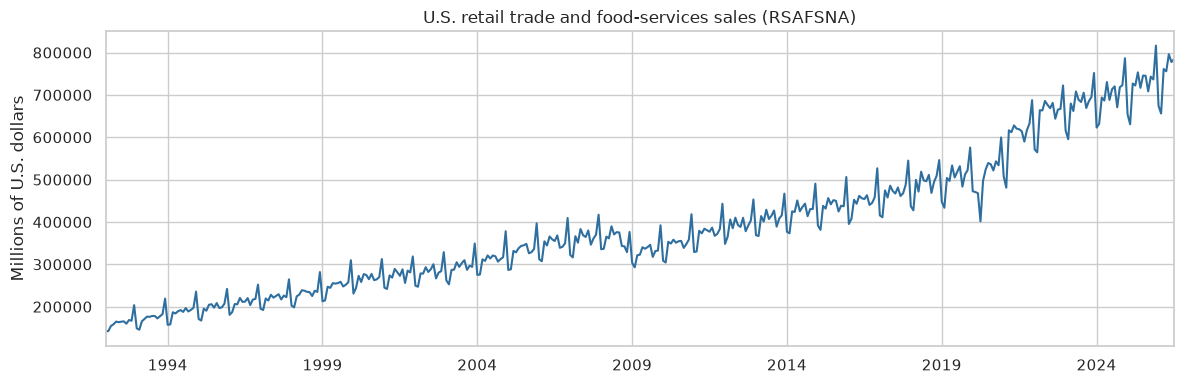

In [2]:
quality = {
    'missing_months': int(series.isna().sum()),
    'duplicate_dates': int(series.index.duplicated().sum()),
    'positive_values': bool((series > 0).all()),
    'frequency': series.index.freqstr,
}
print(quality)

ASSETS = PROJECT_DIR / 'assets'
ASSETS.mkdir(exist_ok=True)
fig, ax = plt.subplots(figsize=(12, 4))
series.plot(ax=ax, color='#2f6f9f')
ax.set(title='U.S. retail trade and food-services sales (RSAFSNA)', ylabel='Millions of U.S. dollars', xlabel='')
fig.tight_layout()
fig.savefig(ASSETS / 'trend.png', dpi=160, bbox_inches='tight')
plt.show()


## 3. Seasonality

Normalize each month by its year's average before averaging across the latest ten years. This separates the recurring within-year profile from the long-run nominal growth trend.


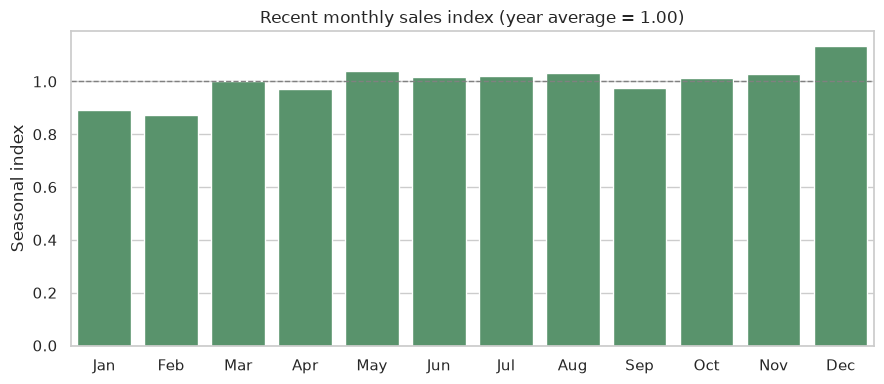

,month,index
4,Jan,0.891576
3,Feb,0.872526
7,Mar,1.000442
0,Apr,0.971018
8,May,1.041436
6,Jun,1.015028
5,Jul,1.021029
1,Aug,1.032871
11,Sep,0.975381
10,Oct,1.014657


In [3]:
seasonal = monthly_seasonality(series)
fig, ax = plt.subplots(figsize=(9, 4))
sns.barplot(data=seasonal, x='month', y='index', color='#4f9d69', ax=ax)
ax.axhline(1.0, color='grey', linestyle='--', linewidth=1)
ax.set(title='Recent monthly sales index (year average = 1.00)', xlabel='', ylabel='Seasonal index')
fig.tight_layout()
fig.savefig(ASSETS / 'seasonality.png', dpi=160, bbox_inches='tight')
plt.show()
seasonal


## 4. Time-based validation

The latest 24 months form the holdout. The candidate is damped-trend Holt–Winters with multiplicative 12-month seasonality. The baseline predicts each month with the observation from 12 months earlier.


In [4]:
result = build_forecast(series, horizon=12, test_months=24)
metrics = pd.DataFrame({
    'model': ['Holt–Winters', 'Year-ago baseline'],
    'MAE_millions': [result.mae, result.naive_mae],
    'RMSE_millions': [result.rmse, np.sqrt(np.mean((result.actual_test - result.naive_forecast) ** 2))],
})
metrics.style.format({'MAE_millions': '${:,.0f}', 'RMSE_millions': '${:,.0f}'})


,model,MAE_millions,RMSE_millions
0,Holt–Winters,"$18,145","$21,869"
1,Year-ago baseline,"$28,509","$31,089"


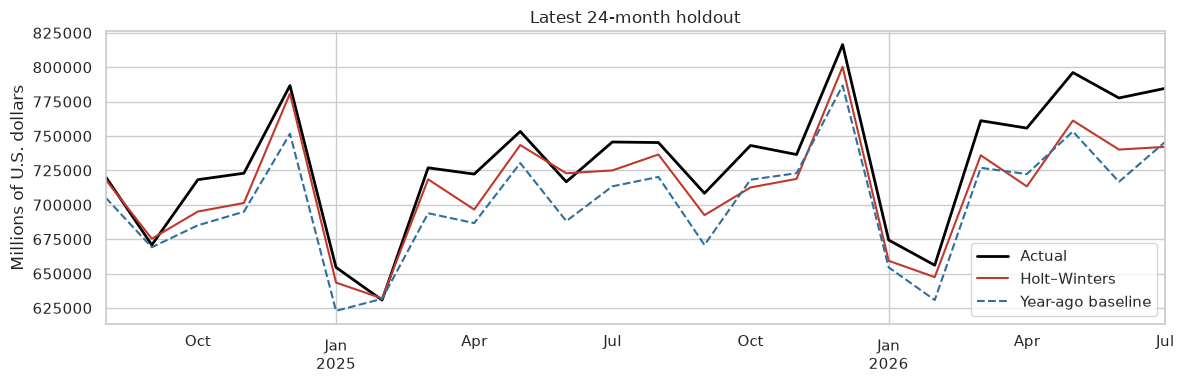

MAE improvement versus baseline: 36.4%


In [5]:
fig, ax = plt.subplots(figsize=(12, 4))
result.actual_test.plot(ax=ax, label='Actual', color='black', linewidth=2)
result.backtest_forecast.plot(ax=ax, label='Holt–Winters', color='#c0392b')
result.naive_forecast.plot(ax=ax, label='Year-ago baseline', color='#2f6f9f', linestyle='--')
ax.set(title='Latest 24-month holdout', ylabel='Millions of U.S. dollars', xlabel='')
ax.legend()
fig.tight_layout()
fig.savefig(ASSETS / 'forecast.png', dpi=160, bbox_inches='tight')
plt.show()
print(f'MAE improvement versus baseline: {result.improvement_pct:.1f}%')


## 5. Future planning range

The central forecast is fitted on all available observations. The band is an empirical approximation based on holdout residual variation; it is not a formal model prediction interval and may understate structural shocks.


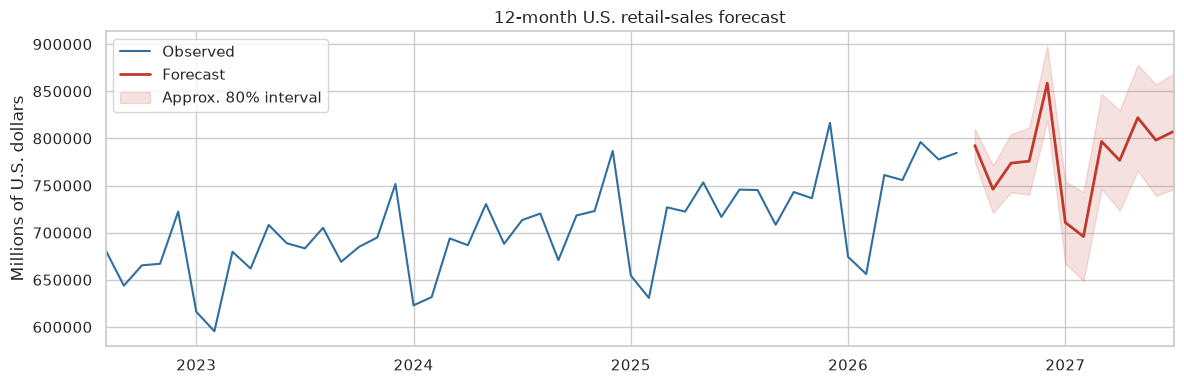

,forecast_millions_usd
2026-08-01,792427.973618
2026-09-01,746017.370282
2026-10-01,773771.374475
2026-11-01,775810.879011
2026-12-01,858648.225624
2027-01-01,710732.491631
2027-02-01,695908.663873
2027-03-01,796697.632738
2027-04-01,776676.692999
2027-05-01,821931.119473


In [6]:
fig, ax = plt.subplots(figsize=(12, 4))
series.iloc[-48:].plot(ax=ax, label='Observed', color='#2f6f9f')
result.future_forecast.plot(ax=ax, label='Forecast', color='#c0392b', linewidth=2)
ax.fill_between(
    result.future_forecast.index,
    result.lower_80.values,
    result.upper_80.values,
    color='#c0392b', alpha=0.15, label='Approx. 80% interval'
)
ax.set(title='12-month U.S. retail-sales forecast', ylabel='Millions of U.S. dollars', xlabel='')
ax.legend()
fig.tight_layout()
fig.savefig(ASSETS / 'future.png', dpi=160, bbox_inches='tight')
plt.show()
result.future_forecast.rename('forecast_millions_usd').to_frame()


## 6. Controlled stakeholder brief

The brief receives the backtest metrics and planning context, not raw data. Forecast calculations remain unchanged whether or not an LLM token is available.


In [7]:
from utils.ai_insights import generate_insights

peak_month = result.future_forecast.idxmax().strftime('%B %Y')
brief = generate_insights({
    'headline': (
        f'The 24-month holdout MAE is ${result.mae / 1_000:,.1f}B, '
        f'{result.improvement_pct:.1f}% better than the year-ago baseline. '
        f'The highest month in the next 12-month forecast is {peak_month}.'
    ),
    'drivers': [
        'Long-run nominal sales growth',
        'Recurring seasonality in the unadjusted series',
        'The recent level and trend at the forecast origin',
    ],
    'recommendation': (
        'Use this national forecast as a macro planning input, refresh monthly, and combine '
        'it with company-level category and price data before inventory decisions.'
    ),
})
content = '# AI-assisted stakeholder brief — U.S. Retail Sales Forecast\n\n' + brief + '\n'
(PROJECT_DIR / 'insights.md').write_text(content, encoding='utf-8')
print(brief)


## What the data says
The 24-month holdout MAE is $18.1B, 36.4% better than the year-ago baseline. The highest month in the next 12-month forecast is December 2026.

## Factors to review
- Long-run nominal sales growth
- Recurring seasonality in the unadjusted series
- The recent level and trend at the forecast origin

## Recommended action
Use this national forecast as a macro planning input, refresh monthly, and combine it with company-level category and price data before inventory decisions.


## 7. Recommendation and limitations

- Use the forecast as a macro budgeting and scenario input, not a store replenishment plan.
- Refresh after each FRED release and track rolling error against the year-ago baseline.
- Add company-level units, price, promotion, category, and inventory data before operational use.
- Treat the latest values as revisable and widen scenarios around shocks.

**Main limitations:** national aggregation, nominal dollars, data revisions, and an approximate uncertainty band.
